### Gyroscope

In [1]:
%reload_ext autoreload
%autoreload 2

In [43]:
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTheta
from spyglass.shijiegu.load import load_position
from spyglass.shijiegu.ripple_add_replay import select_subset_helper_pd

from spyglass.common.common_behav import RawPosition
from spyglass.common.common_behav import VideoFile
import os

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pynwb

In [8]:
from trodestrack.models.ekf import EKFConfig, extended_kalman_filter

In [9]:
### 
### 1. Load Gyro data
### 2. Load animal position
### 3. Call Trodestrack to interpolate
###

In [10]:
## start load gyro and acc data

In [251]:
nwb_file_name = 'lewis20240109.nwb'
nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)

In [40]:
# session information
session_interval, position_interval = runSessionNames(nwb_copy_file_name)
session_name = session_interval[0]
pos_name = position_interval[0]

q = {"nwb_file_name": nwb_copy_file_name,
     "epoch":int(session_name[:2]),
     "proportion":str(0.1),
     "delta_t_minus":5,
     "delta_t_plus":5}
                    
log_df = ChangeofMindTheta().fetch1_dataframe(q)
log_df_short = log_df[log_df.long_theta]
log_df_short

,timestamp_H,Home,timestamp_O,OuterWellIndex,rewardNum,change_of_mind,long_theta,theta_dev,long_theta_intervals,change_of_mind_num,...,proportion_arm2,proportion_arm3,proportion_arm4,CoMNum_by_time,CoMNum_by_arm,current,future_H,future_O,past,past_reward
55,1.704829e+09,1.0,1.704829e+09,2.0,2.0,True,True,84.836779,"[(1704829112.970363, 1704829113.026363)]",[0],...,0.420471,0.0,0.217687,3,3,2.0,2.0,4.0,3.0,1.0
63,1.704829e+09,1.0,1.704829e+09,1.0,2.0,True,True,[],"[(1704829384.7903116, 1704829384.8843117), (17...","[0, 0]",...,0.504950,0.0,0.000000,1,1,1.0,1.0,2.0,3.0,3.0
64,1.704829e+09,1.0,1.704829e+09,2.0,2.0,True,True,[],"[(1704829416.2043056, 1704829416.2943056), (17...","[0, 0]",...,0.000000,0.0,0.503644,1,1,2.0,2.0,1.0,1.0,1.0


In [356]:
trialIDs = log_df.index
(t0,t1) = (log_df.loc[trialIDs[10]].timestamp_H, 
           log_df.loc[trialIDs[10]].timestamp_O)

In [357]:
indices_list = [5,0,1]

# gyro
gyrodata=nwbf.processing['analog']['analog'].time_series['analog'].data
# 0: Accel X, 1: Accel Y, 2: Gyro Z
# 3: Gyro Y, 4: Accel Z, 5: Gyro X
gyrotimestamps=nwbf.processing['analog']['analog'].time_series['analog'].timestamps


timestamp_ind = np.logical_and(gyrotimestamps >= t0, gyrotimestamps <= t1)
gyro_data_trial = gyrodata[timestamp_ind][:,indices_list].astype("float64")
gyro_data_trial[:,0] *= 0.061
gyro_data_trial[:,1] *= 0.000061 * 9.8
gyro_data_trial[:,2] *= 0.000061 * 9.8
gyro_time_trial = gyrotimestamps[timestamp_ind]

In [359]:
# load position

# position
key = {"nwb_file_name": nwb_copy_file_name,"interval_list_name":pos_name}
raw_position = RawPosition.PosObject & key
spatial_series = raw_position.fetch_nwb()[0]["raw_position"]
spatial_df = raw_position.fetch1_dataframe()

PIXEL_TO_M = spatial_series.conversion # M

[2025-11-23 10:32:56,277][WARNING]: Skipped checksum for file with hash: e630fc87-b027-ed25-8410-26bf159c7e37, and path: /stelmo/nwb/raw/lewis20240109_.nwb
[2025-11-23 10:32:56,311][WARNING]: Skipped checksum for file with hash: e630fc87-b027-ed25-8410-26bf159c7e37, and path: /stelmo/nwb/raw/lewis20240109_.nwb


In [360]:
spatial_subset_df = select_subset_helper_pd(spatial_df, (t0, t1))

# Define LEDs
front_LED = np.hstack(
    (np.array(spatial_subset_df.xloc).astype(float).reshape((-1,1)),
     np.array(spatial_subset_df.yloc).astype(float).reshape((-1,1))))
back_LED = np.hstack(
    (np.array(spatial_subset_df.xloc2).astype(float).reshape((-1,1)),
     np.array(spatial_subset_df.yloc2).astype(float).reshape((-1,1))))

# Convert to cm
back_LED *= PIXEL_TO_M
front_LED *= PIXEL_TO_M

LED_data_front_trial = front_LED
LED_data_back_trial = back_LED
LED_time_trial = np.array(spatial_subset_df.index)

In [361]:
data_dict = {"t_imu": gyro_time_trial,
             "U_imu": gyro_data_trial,
             "t_cam_exp": LED_time_trial,
             "Z_cam_led1": LED_data_back_trial,
             "Z_cam_led2": LED_data_front_trial,
             "mask_cam": np.zeros_like(LED_time_trial) == 0
            }

In [362]:
print("   Running EKF filter...")
result_test = extended_kalman_filter(
        ekf_config=ekf_config,
        t_imu=data_dict["t_imu"], # time stamps of IMU, of shape (T,)
        U_imu=data_dict["U_imu"], # gyroscope, accel x and accel y, of shape (T, 3)
        t_cam=data_dict["t_cam_exp"], # time stamps of camera data, of shape (T',) lower sampling rate
        Z_cam_led1=data_dict["Z_cam_led1"], # LED1 = back LED location, of shape (T', 2) 
        Z_cam_led2=data_dict["Z_cam_led2"], # LED2 = front LED location, of shape (T', 2) 
        mask_cam=data_dict["mask_cam"], # occlude
    )

   Running EKF filter...


In [363]:
X_est = np.array(result_test.filtered_means)
P_est = np.array(result_test.filtered_covariances)

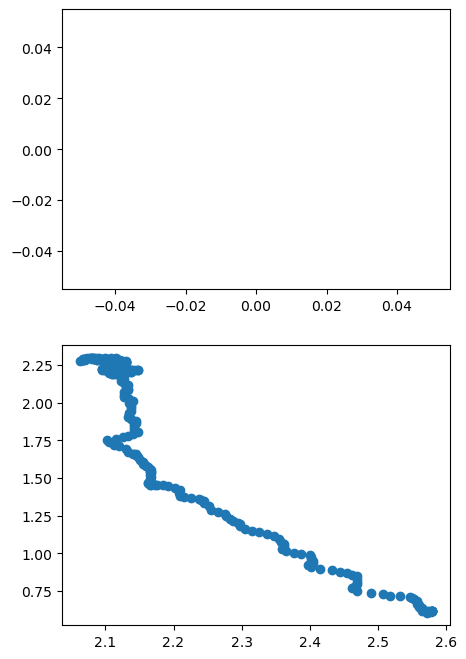

In [364]:
fig, axes = plt.subplots(2,1, figsize = (5,8))
axes[0].scatter(X_est[:,0], X_est[:,1])
axes[1].scatter(data_dict["Z_cam_led1"][:,0], data_dict["Z_cam_led1"][:,1])
#axes[1].scatter(data_dict["Z_cam_led2"][:,0], data_dict["Z_cam_led2"][:,1])

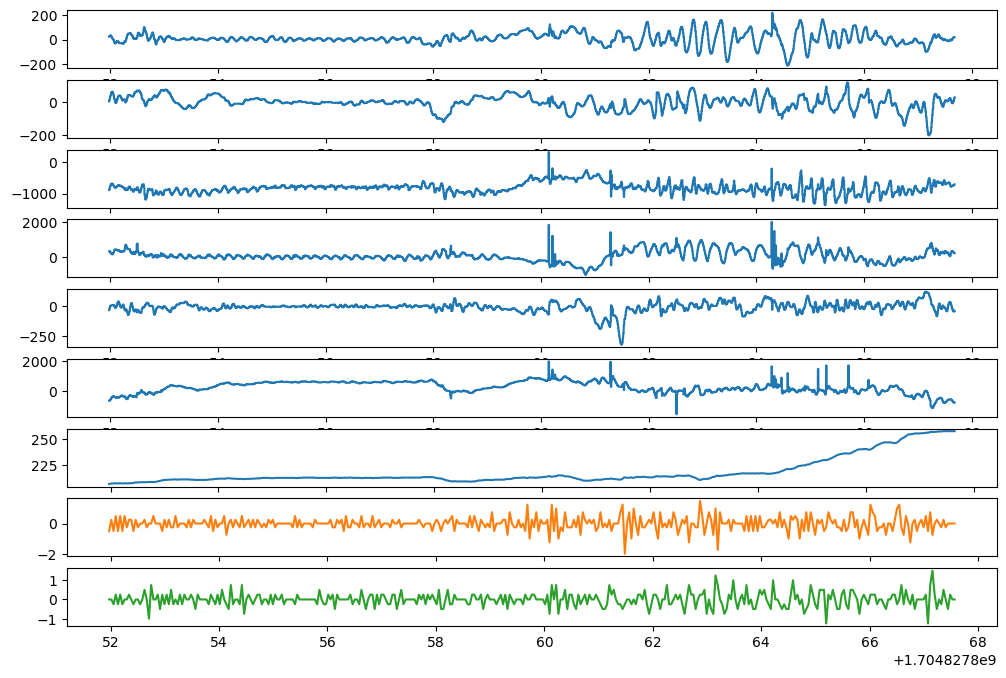

In [344]:
fig, axes = plt.subplots(9,1, figsize = (12,8))

for i in range(6):
    axes[i].plot(gyro_time_trial, gyrodata[timestamp_ind][:,i] * 0.061)

axes[6].plot(data_dict["t_cam_exp"], data_dict["Z_cam_led1"][:,0])
axes[7].plot(data_dict["t_cam_exp"][:-2], np.diff(np.diff(data_dict["Z_cam_led1"][:,0])),color = 'C1')
axes[8].plot(data_dict["t_cam_exp"][:-2], np.diff(np.diff(data_dict["Z_cam_led1"][:,1])),color = 'C2')

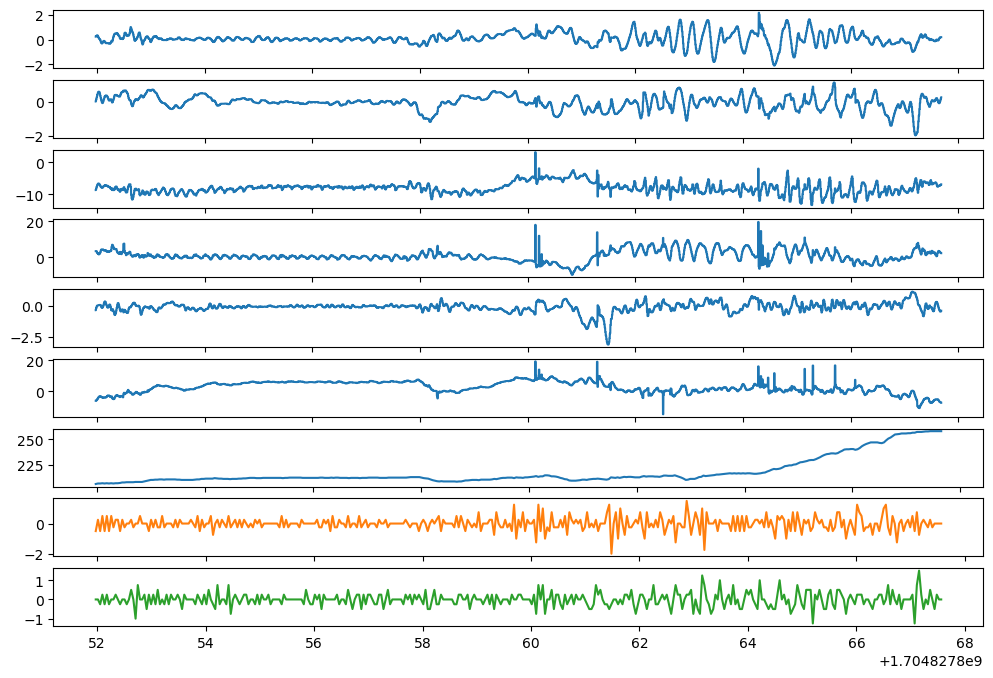

In [343]:
fig, axes = plt.subplots(9,1, figsize = (12,8))

for i in range(6):
    axes[i].plot(gyro_time_trial, gyrodata[timestamp_ind][:,i] * 0.000061 * 9.8)

axes[6].plot(data_dict["t_cam_exp"], data_dict["Z_cam_led1"][:,0])
axes[7].plot(data_dict["t_cam_exp"][:-2], np.diff(np.diff(data_dict["Z_cam_led1"][:,0])),color = 'C1')
axes[8].plot(data_dict["t_cam_exp"][:-2], np.diff(np.diff(data_dict["Z_cam_led1"][:,1])),color = 'C2')

In [70]:
# Compute metrics
t_cam = data_dict["t_cam_exp"]
t_imu = data_dict["t_imu"]
X_truth = data_dict["Z_cam_led1"]
X_truth_cam = np.column_stack([np.interp(t_cam, t_imu, X_truth[:, i]) for i in range(5)])
X_truth_cam[:, 4] = interp_angle(t_cam, t_imu, X_truth[:, 4])

X_est = np.array(result_test.filtered_means)
P_est = np.array(result_test.filtered_covariances)

pos_rmse_cm = compute_position_rmse(X_truth_cam[:, :2] * 100, X_est[:, :2] * 100)

ValueError: fp and xp are not of the same length.

In [80]:
#sim_circular["mask_cam"]

In [ ]:
t_imu=sim_circular["t_imu"], # time stamps of IMU, of shape (T,)
        U_imu=sim_circular["U_imu"], # gyroscope, accel x and accel y, of shape (T, 3)
        t_cam=sim_circular["t_cam_exp"], # time stamps of camera data, of shape (T',) lower sampling rate
        Z_cam_led1=sim_circular["Z_cam_led1"], # LED1 = back LED location, of shape (T', 2) 
        Z_cam_led2=sim_circular["Z_cam_led2"], # LED2 = front LED location, of shape (T', 2) 
        mask_cam=sim_circular["mask_cam"], # occlude

In [ ]:
## end load gyro and acc data

In [13]:
from trodestrack.models.ekf import EKFConfig, extended_kalman_filter
from trodestrack.models.state_layout import get_layout
from trodestrack.qa.metrics import compute_nees, compute_position_rmse
from trodestrack.sim.simple import (
    SimpleSimConfig,
    simulate_circular,
    simulate_constant_velocity,
    simulate_stationary,
)
from trodestrack.viz.styles import COLORS, apply_tufte_style
from trodestrack.sim.utils import interp_angle

In [77]:
# Simulation config using REALISTIC SpikeGadgets IMU specifications
sim_config = SimpleSimConfig(
        duration_s=10.0,  # 10 second runs (enough to see convergence)
        fs_imu=200.0,  # IMU at 200 Hz (higher than SpikeGadgets 104 Hz for accuracy)
        fs_cam=30.0,  # Camera at 30 Hz (typical video frame rate)
        # SpikeGadgets IMU specs (from PRD.md):
        gyro_noise_density=0.000175,  # 0.01 °/s/√Hz (SpikeGadgets spec)
        accel_noise_density=0.00196,  # 0.2 mg/√Hz (SpikeGadgets spec)
        gyro_bias_std=0.001,  # ~0.06 °/s bias std
        accel_bias_std=0.01,  # ~1 mg bias std
        cam_noise_std=0.005,  # 5 mm camera noise (realistic DLC/LED)
        cam_dropout_prob=0,  # NO DROPOUTS (ideal conditions)
    )

In [15]:
ekf_config = EKFConfig(
        # Process noise spectral densities (Q matrix continuous-time variances)
        # Tuned to balance accuracy and well-calibrated uncertainty (NEES ≈ 8)
        process_noise_pos=2e-3,  # m^2/s^3 - accounts for unmodeled dynamics
        process_noise_vel=1e-1,  # (m/s)^2/s - velocity model uncertainty
        process_noise_heading=1e-3,  # rad^2/s - heading drift between measurements
        process_noise_gyro_bias=5e-7,  # (rad/s)^2/s - gyro bias random walk
        process_noise_accel_bias=5e-5,  # (m/s²)^2/s - accel bias random walk
        # Measurement noise (R matrix, units: variance)
        measurement_noise_pos=0.005**2,  # m^2 - match camera noise (5mm)
        measurement_noise_heading=0.05**2,  # rad^2 - heading from dual LEDs (~3°)
        # IMU noise densities (SpikeGadgets specs - MUST match simulation!)
        imu_gyro_noise_density=0.000175,  # rad/s/√Hz (0.01 °/s/√Hz SpikeGadgets)
        imu_accel_noise_density=0.00196,  # m/s²/√Hz (0.2 mg/√Hz SpikeGadgets)
        # Physics
        damping_coeff=0.5,  # 1/s - velocity damping coefficient
        led_distance=0.04,  # m - 4 cm LED spacing (typical)
        # Advanced features
        use_heading_measurement=True,  # Use dual-LED heading
        enable_zupt=False,  # ZUPT not needed without dropouts
    )

In [78]:
print("   Running simulation...")
sim_circular = simulate_circular(
        sim_config,
        center=np.array([1.0, 1.0]),
        radius=0.5,  # 50 cm radius
        angular_velocity=0.5,  # 0.5 rad/s ≈ 28°/s
        seed=42,
    )

   Running simulation...


In [17]:
print("   Running EKF filter...")
result_circular = extended_kalman_filter(
        ekf_config=ekf_config,
        t_imu=sim_circular["t_imu"], # time stamps of IMU, of shape (T,)
        U_imu=sim_circular["U_imu"], # gyroscope, accel x and accel y, of shape (T, 3)
        t_cam=sim_circular["t_cam_exp"], # time stamps of camera data, of shape (T',) lower sampling rate
        Z_cam_led1=sim_circular["Z_cam_led1"], # LED1 = back LED location, of shape (T', 2) 
        Z_cam_led2=sim_circular["Z_cam_led2"], # LED2 = front LED location, of shape (T', 2) 
        mask_cam=sim_circular["mask_cam"], # occlude
    )

   Running EKF filter...


In [18]:
#sim_circular["mask_cam"]

In [19]:
# Compute metrics
t_cam = sim_circular["t_cam_exp"]
t_imu = sim_circular["t_imu"]
X_truth = sim_circular["X_truth"]
X_truth_cam = np.column_stack([np.interp(t_cam, t_imu, X_truth[:, i]) for i in range(5)])
X_truth_cam[:, 4] = interp_angle(t_cam, t_imu, X_truth[:, 4])

X_est = np.array(result_circular.filtered_means)
P_est = np.array(result_circular.filtered_covariances)

pos_rmse_cm = compute_position_rmse(X_truth_cam[:, :2] * 100, X_est[:, :2] * 100)

Text(0.5, 1.0, 'animal location x')

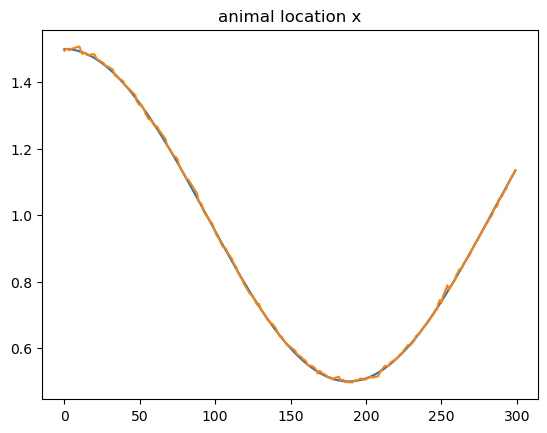

In [20]:
plt.plot(X_truth_cam[:, 0])
plt.plot(X_est[:, 0])
plt.title("animal location x")

Text(0.5, 1.0, 'head direction')

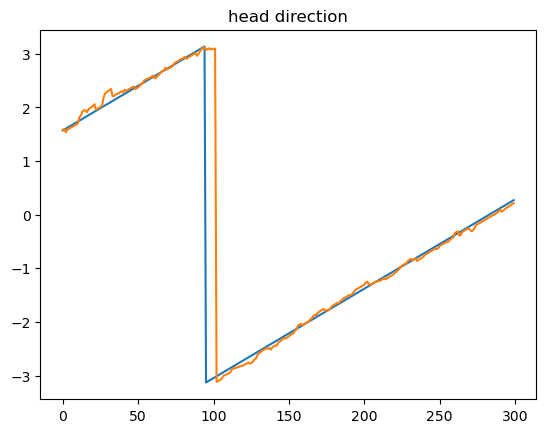

In [21]:
plt.plot(X_truth_cam[:, 4])
plt.plot(X_est[:, 4])
plt.title("head direction")